In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load data
print("\n📂 Loading data...")
df_trans = pd.read_csv('../data/eda/transactions_unified.csv')
df_trans['TransactionDate'] = pd.to_datetime(df_trans['TransactionDate'])

print(f"✅ Loaded {df_trans.shape[0]:,} transactions")


📂 Loading data...
✅ Loaded 48,510 transactions


# TIME-BASED FEATURES

In [4]:
print("\n⏰ Creating Time-Based Features...")

df_trans['Hour'] = df_trans['TransactionDate'].dt.hour
df_trans['Minute'] = df_trans['TransactionDate'].dt.minute
df_trans['DayOfWeek'] = df_trans['TransactionDate'].dt.dayofweek  # 0=Monday
df_trans['Day'] = df_trans['TransactionDate'].dt.day
df_trans['Month'] = df_trans['TransactionDate'].dt.month
df_trans['Year'] = df_trans['TransactionDate'].dt.year
df_trans['Quarter'] = df_trans['TransactionDate'].dt.quarter

# Categorical time features
df_trans['IsWeekend'] = (df_trans['DayOfWeek'] >= 5).astype(int)
df_trans['IsBusinessHour'] = ((df_trans['Hour'] >= 9) & (df_trans['Hour'] <= 17)).astype(int)
df_trans['IsLateNight'] = ((df_trans['Hour'] >= 22) | (df_trans['Hour'] <= 5)).astype(int)
df_trans['IsMorning'] = ((df_trans['Hour'] >= 6) & (df_trans['Hour'] <= 11)).astype(int)
df_trans['IsAfternoon'] = ((df_trans['Hour'] >= 12) & (df_trans['Hour'] <= 17)).astype(int)
df_trans['IsEvening'] = ((df_trans['Hour'] >= 18) & (df_trans['Hour'] <= 21)).astype(int)

print(f"   ✅ Created {len(['Hour', 'Minute', 'DayOfWeek', 'Day', 'Month', 'Year', 'Quarter', 'IsWeekend', 'IsBusinessHour', 'IsLateNight', 'IsMorning', 'IsAfternoon', 'IsEvening'])} time features")


⏰ Creating Time-Based Features...
   ✅ Created 13 time features


# AMOUNT-BASED FEATURES

In [5]:
print("\n💰 Creating Amount-Based Features...")

# Amount statistics
df_trans['Amount_Log'] = np.log1p(df_trans['Amount'])  # Log transformation
df_trans['Amount_Sqrt'] = np.sqrt(df_trans['Amount'])  # Square root
df_trans['Amount_Squared'] = df_trans['Amount'] ** 2   # Squared

# Amount brackets (categorical)
df_trans['Amount_Bracket'] = pd.cut(
    df_trans['Amount'],
    bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000, float('inf')],
    labels=['<10', '10-50', '50-100', '100-500', '500-1k', '1k-5k', '5k-10k', '10k-50k', '>50k']
)

# High amount flags
df_trans['Is_High_Amount'] = (df_trans['Amount'] > df_trans['Amount'].quantile(0.90)).astype(int)
df_trans['Is_Very_High_Amount'] = (df_trans['Amount'] > df_trans['Amount'].quantile(0.95)).astype(int)
df_trans['Is_Max_Amount'] = (df_trans['Amount'] > df_trans['Amount'].quantile(0.99)).astype(int)

print(f"   ✅ Created amount features: Amount_Log, Amount_Sqrt, Amount_Squared, Amount_Bracket, Is_High_Amount, Is_Very_High_Amount, Is_Max_Amount")



💰 Creating Amount-Based Features...
   ✅ Created amount features: Amount_Log, Amount_Sqrt, Amount_Squared, Amount_Bracket, Is_High_Amount, Is_Very_High_Amount, Is_Max_Amount


# BEHAVIORAL FEATURES (Per Customer)

In [6]:
print("\n👤 Creating Behavioral Features...")

# Customer statistics
customer_stats = df_trans.groupby('OriginCustomerID').agg({
    'TransactionID': 'count',
    'Amount': ['mean', 'std', 'max', 'min', 'median', 'sum'],
    'Hour': ['mean', 'median']
}).reset_index()

customer_stats.columns = ['CustomerID', 'TotalTransactions', 'AvgAmount', 'StdAmount', 
                         'MaxAmount', 'MinAmount', 'MedianAmount', 'TotalAmount',
                         'AvgHour', 'MedianHour']

# Merge back
df_trans = df_trans.merge(customer_stats, left_on='OriginCustomerID', 
                          right_on='CustomerID', how='left')

# Customer's typical patterns
customer_typical = df_trans.groupby('OriginCustomerID').agg({
    'Amount': [lambda x: x.quantile(0.75), lambda x: x.quantile(0.90)],
    'Hour': 'median'
}).reset_index()

customer_typical.columns = ['CustomerID', 'TypicalHighAmount', 'TypicalVeryHighAmount', 'TypicalHour']

df_trans = df_trans.merge(customer_typical, left_on='OriginCustomerID', 
                          right_on='CustomerID', how='left')

# Deviation features
df_trans['Amount_Deviation'] = df_trans['Amount'] - df_trans['AvgAmount']
df_trans['Amount_Deviation_Pct'] = (df_trans['Amount_Deviation'] / df_trans['AvgAmount']) * 100
df_trans['Amount_Ratio_To_Avg'] = df_trans['Amount'] / df_trans['AvgAmount']
df_trans['Hour_Deviation'] = abs(df_trans['Hour'] - df_trans['TypicalHour'])

# Unusual amount flags
df_trans['Is_Unusual_Amount'] = (df_trans['Amount'] > df_trans['TypicalHighAmount'] * 2).astype(int)
df_trans['Is_Very_Unusual_Amount'] = (df_trans['Amount'] > df_trans['TypicalVeryHighAmount'] * 2).astype(int)
df_trans['Is_Above_Avg'] = (df_trans['Amount'] > df_trans['AvgAmount']).astype(int)

print(f"   ✅ Created behavioral features: Amount_Deviation, Amount_Ratio_To_Avg, Hour_Deviation, Is_Unusual_Amount, Is_Above_Avg")


👤 Creating Behavioral Features...
   ✅ Created behavioral features: Amount_Deviation, Amount_Ratio_To_Avg, Hour_Deviation, Is_Unusual_Amount, Is_Above_Avg


# FREQUENCY FEATURES 

In [ ]:
print("\n📊 Creating Frequency Features...")

# Sort by customer and date
df_trans = df_trans.sort_values(['OriginCustomerID', 'TransactionDate']).reset_index(drop=True)

# Time since last transaction
df_trans['Time_Since_Last'] = df_trans.groupby('OriginCustomerID')['TransactionDate'].diff().dt.total_seconds() / 3600

# FIX: Simple rolling count using a loop (works reliably)
def calculate_rolling_counts(df, customer_col, date_col, window_hours):
    """
    Calculate rolling count of transactions within a time window per customer
    """
    # Initialize result array
    result = np.zeros(len(df), dtype=int)
    
    # Group by customer
    for customer in df[customer_col].unique():
        # Get indices for this customer
        customer_mask = df[customer_col] == customer
        customer_indices = df[customer_mask].index.tolist()
        
        # Get dates for this customer
        customer_dates = df.loc[customer_mask, date_col].values
        
        # For each transaction, count how many in the last window_hours
        for i, idx in enumerate(customer_indices):
            cutoff = customer_dates[i] - pd.Timedelta(hours=window_hours)
            # Count transactions within the window (including current)
            count = np.sum((customer_dates <= customer_dates[i]) & (customer_dates >= cutoff))
            result[idx] = count
    
    return result

# Calculate rolling counts for different windows
print("   Calculating 1-hour rolling count...")
df_trans['Transactions_Last_Hour'] = calculate_rolling_counts(
    df_trans, 'OriginCustomerID', 'TransactionDate', 1
)

print("   Calculating 24-hour rolling count...")
df_trans['Transactions_Last_Day'] = calculate_rolling_counts(
    df_trans, 'OriginCustomerID', 'TransactionDate', 24
)

print("   Calculating 168-hour (7-day) rolling count...")
df_trans['Transactions_Last_Week'] = calculate_rolling_counts(
    df_trans, 'OriginCustomerID', 'TransactionDate', 168
)

# Fill NaN values (shouldn't be any now, but just in case)
df_trans['Transactions_Last_Hour'] = df_trans['Transactions_Last_Hour'].fillna(0).astype(int)
df_trans['Transactions_Last_Day'] = df_trans['Transactions_Last_Day'].fillna(0).astype(int)
df_trans['Transactions_Last_Week'] = df_trans['Transactions_Last_Week'].fillna(0).astype(int)
df_trans['Time_Since_Last'] = df_trans['Time_Since_Last'].fillna(24 * 365)  # Assume 1 year for first transaction

# High frequency flags
df_trans['High_Frequency_Hour'] = (df_trans['Transactions_Last_Hour'] > 5).astype(int)
df_trans['High_Frequency_Day'] = (df_trans['Transactions_Last_Day'] > 20).astype(int)
df_trans['Is_First_Transaction'] = (df_trans['Time_Since_Last'] > 24 * 30).astype(int)  # No transaction in 30 days

print(f"   ✅ Created frequency features:")
print(f"      - Time_Since_Last: {df_trans['Time_Since_Last'].notna().sum():,} values")
print(f"      - Transactions_Last_Hour: {df_trans['Transactions_Last_Hour'].sum():,} total")
print(f"      - Transactions_Last_Day: {df_trans['Transactions_Last_Day'].sum():,} total")
print(f"      - Transactions_Last_Week: {df_trans['Transactions_Last_Week'].sum():,} total")
print(f"      - High_Frequency_Hour: {df_trans['High_Frequency_Hour'].sum():,} flagged")
print(f"      - High_Frequency_Day: {df_trans['High_Frequency_Day'].sum():,} flagged")
print(f"      - Is_First_Transaction: {df_trans['Is_First_Transaction'].sum():,} flagged")


📊 Creating Frequency Features...
   Calculating 1-hour rolling count...
   Calculating 24-hour rolling count...
   Calculating 168-hour (7-day) rolling count...
   ✅ Created frequency features:
      - Time_Since_Last: 48,510 values
      - Transactions_Last_Hour: 48,694 total
      - Transactions_Last_Day: 50,921 total
      - Transactions_Last_Week: 65,114 total
      - High_Frequency_Hour: 0 flagged
      - High_Frequency_Day: 0 flagged
      - Is_First_Transaction: 14,707 flagged


# LOCATION FEATURES

In [11]:
print("\n📍 Creating Location Features...")

# Check if we have the necessary columns
if 'BranchID' in df_trans.columns and 'OriginCustomerID' in df_trans.columns:
    
    # Customer's home branch (most common branch)
    # Use OriginCustomerID as the customer identifier
    customer_home_branch = df_trans.groupby('OriginCustomerID')['BranchID'].agg(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else None
    ).reset_index()
    customer_home_branch.columns = ['OriginCustomerID', 'HomeBranchID']
    
    # Merge back - using OriginCustomerID to avoid duplicate column issues
    df_trans = df_trans.merge(
        customer_home_branch, 
        on='OriginCustomerID', 
        how='left'
    )
    
    # Create flag for different branch
    df_trans['Is_Different_Branch'] = (
        (df_trans['BranchID'] != df_trans['HomeBranchID']) & 
        (df_trans['HomeBranchID'].notna())
    ).astype(int)
    
    print(f"   ✅ Created location features: Is_Different_Branch")
    print(f"      - Different Branch: {df_trans['Is_Different_Branch'].sum():,} transactions")
    print(f"      - Same Branch: {(df_trans['Is_Different_Branch'] == 0).sum():,} transactions")
    
    # Drop the HomeBranchID column to avoid confusion (optional)
    # df_trans = df_trans.drop(columns=['HomeBranchID'])
    
else:
    print("   ⚠️ BranchID or OriginCustomerID not found - skipping location features")
    
    # Create a placeholder feature if needed
    df_trans['Is_Different_Branch'] = 0
    print("   ℹ️ Created placeholder Is_Different_Branch = 0")


📍 Creating Location Features...
   ✅ Created location features: Is_Different_Branch
      - Different Branch: 45,113 transactions
      - Same Branch: 3,397 transactions


# INTERACTION FEATURES

In [12]:
print("\n🔄 Creating Interaction Features...")

# Check if required columns exist before creating interactions
required_cols = ['Amount', 'IsLateNight', 'IsWeekend', 'Is_Different_Branch', 'High_Frequency_Hour']

# Ensure all required columns exist
for col in required_cols:
    if col not in df_trans.columns:
        print(f"   ⚠️ Column '{col}' not found - creating placeholder")
        if col == 'Is_Different_Branch':
            df_trans[col] = 0
        elif col == 'High_Frequency_Hour':
            df_trans[col] = 0
        elif col in ['IsLateNight', 'IsWeekend']:
            df_trans[col] = 0

# Amount × Time interactions
df_trans['Amount_LateNight'] = df_trans['Amount'] * df_trans['IsLateNight']
df_trans['Amount_Weekend'] = df_trans['Amount'] * df_trans['IsWeekend']

# Amount × Location interactions
df_trans['Amount_DifferentBranch'] = df_trans['Amount'] * df_trans['Is_Different_Branch']

# Frequency × Amount interactions
df_trans['Amount_HighFreq'] = df_trans['Amount'] * df_trans['High_Frequency_Hour']

# Time × Location interactions
df_trans['LateNight_DifferentBranch'] = df_trans['IsLateNight'] * df_trans['Is_Different_Branch']

print(f"   ✅ Created interaction features:")
print(f"      - Amount_LateNight: mean = {df_trans['Amount_LateNight'].mean():.2f}")
print(f"      - Amount_Weekend: mean = {df_trans['Amount_Weekend'].mean():.2f}")
print(f"      - Amount_DifferentBranch: mean = {df_trans['Amount_DifferentBranch'].mean():.2f}")
print(f"      - Amount_HighFreq: mean = {df_trans['Amount_HighFreq'].mean():.2f}")
print(f"      - LateNight_DifferentBranch: {df_trans['LateNight_DifferentBranch'].sum():,} flagged")



🔄 Creating Interaction Features...
   ✅ Created interaction features:
      - Amount_LateNight: mean = 834.27
      - Amount_Weekend: mean = 715.14
      - Amount_DifferentBranch: mean = 2329.46
      - Amount_HighFreq: mean = 0.00
      - LateNight_DifferentBranch: 14,949 flagged


## FEATURE ENCODING

In [13]:
# Select features for encoding
categorical_features = ['TypeName', 'Amount_Bracket', 'IsWeekend', 'IsBusinessHour', 
                        'IsLateNight', 'IsMorning', 'IsAfternoon', 'IsEvening',
                        'Is_Different_Branch', 'High_Frequency_Hour', 'High_Frequency_Day',
                        'Is_High_Amount', 'Is_Very_High_Amount', 'Is_Max_Amount',
                        'Is_Unusual_Amount', 'Is_Above_Avg', 'Is_First_Transaction']

# Keep only categorical features that exist
categorical_features = [f for f in categorical_features if f in df_trans.columns]

print(f"\n📝 Categorical Features to Encode: {len(categorical_features)}")

# 2a. One-Hot Encoding for nominal categories
nominal_features = ['TypeName', 'Amount_Bracket']
nominal_features = [f for f in nominal_features if f in df_trans.columns]

df_encoded = pd.DataFrame()
if nominal_features:
    df_encoded = pd.get_dummies(df_trans[nominal_features], prefix=nominal_features, drop_first=True)
    print(f"   ✅ One-Hot Encoding: {len(nominal_features)} features → {df_encoded.shape[1]} new features")

# 2b. Binary features (already encoded)
binary_features = ['IsWeekend', 'IsBusinessHour', 'IsLateNight', 'IsMorning', 'IsAfternoon', 
                   'IsEvening', 'Is_Different_Branch', 'High_Frequency_Hour', 'High_Frequency_Day',
                   'Is_High_Amount', 'Is_Very_High_Amount', 'Is_Max_Amount',
                   'Is_Unusual_Amount', 'Is_Above_Avg', 'Is_First_Transaction']
binary_features = [f for f in binary_features if f in df_trans.columns]

if binary_features:
    binary_encoded = df_trans[binary_features].copy()
    print(f"   ✅ Binary Encoding: {len(binary_features)} features ready")

# 2c. Combine all encoded features
encoded_features = pd.DataFrame()

# Add binary features
if binary_features:
    encoded_features = pd.concat([encoded_features, df_trans[binary_features]], axis=1)

# Add one-hot encoded features
if nominal_features and not df_encoded.empty:
    encoded_features = pd.concat([encoded_features, df_encoded], axis=1)

print(f"\n📊 Encoded Features Shape: {encoded_features.shape[1]} columns")


📝 Categorical Features to Encode: 17
   ✅ One-Hot Encoding: 2 features → 11 new features
   ✅ Binary Encoding: 15 features ready

📊 Encoded Features Shape: 26 columns


# FEATURE SCALING

In [14]:
print("\n" + "="*80)
print("📌 STEP 3: FEATURE SCALING")
print("="*80)

# Select numerical features for scaling
numerical_features = ['Amount', 'Amount_Log', 'Amount_Sqrt', 'Amount_Squared',
                     'Hour', 'Minute', 'DayOfWeek', 'Day', 'Month', 'Year', 'Quarter',
                     'TotalTransactions', 'AvgAmount', 'StdAmount', 'MaxAmount', 'MinAmount', 
                     'MedianAmount', 'TotalAmount', 'AvgHour', 'MedianHour',
                     'TypicalHighAmount', 'TypicalVeryHighAmount', 'TypicalHour',
                     'Amount_Deviation', 'Amount_Deviation_Pct', 'Amount_Ratio_To_Avg',
                     'Hour_Deviation', 'Time_Since_Last', 'Transactions_Last_Hour', 
                     'Transactions_Last_Day', 'Transactions_Last_Week',
                     'Amount_LateNight', 'Amount_Weekend', 'Amount_DifferentBranch', 
                     'Amount_HighFreq', 'LateNight_DifferentBranch']

# Keep only numerical features that exist
numerical_features = [f for f in numerical_features if f in df_trans.columns]

print(f"\n🔢 Numerical Features to Scale: {len(numerical_features)}")

# 3a. Standard Scaling (StandardScaler)
scaler_standard = StandardScaler()
scaled_standard = scaler_standard.fit_transform(df_trans[numerical_features])
scaled_standard_df = pd.DataFrame(scaled_standard, columns=numerical_features, 
                                  index=df_trans.index)
scaled_standard_df.columns = [f'{col}_standard' for col in numerical_features]

print(f"   ✅ Standard Scaling: {len(numerical_features)} features scaled")

print(f"   ✅ Selected Standard Scaling for modeling")


📌 STEP 3: FEATURE SCALING

🔢 Numerical Features to Scale: 36
   ✅ Standard Scaling: 36 features scaled
   ✅ Selected Standard Scaling for modeling


# COMBINE ALL FEATURES

In [15]:
print("\n" + "="*80)
print("📊 COMBINING ALL FEATURES")
print("="*80)

# Create final feature set
final_features = pd.concat([
    scaled_standard_df,  # Numerical features (scaled)
    encoded_features     # Categorical features (encoded)
], axis=1)

print(f"\n📊 Final Feature Set:")
print(f"   Total Features: {final_features.shape[1]}")
print(f"   Rows: {final_features.shape[0]:,}")


📊 COMBINING ALL FEATURES

📊 Final Feature Set:
   Total Features: 62
   Rows: 48,510


# CREATE TARGET VARIABLE

In [16]:
print("\n🎯 Creating Target Variable...")

# Create target (High-Value + suspicious patterns)
df_trans['is_fraud_proxy'] = (
    (df_trans['Amount'] > df_trans['Amount'].quantile(0.95)) & 
    (df_trans['Is_Different_Branch'] == 1) & 
    (df_trans['IsLateNight'] == 1) &
    (df_trans['High_Frequency_Hour'] == 1)
).astype(int)

print(f"   Fraud Proxy Count: {df_trans['is_fraud_proxy'].sum():,} ({df_trans['is_fraud_proxy'].mean()*100:.2f}%)")



🎯 Creating Target Variable...
   Fraud Proxy Count: 0 (0.00%)


# FEATURE SELECTION

In [17]:
print("\n" + "="*80)
print("📌 STEP 4: FEATURE SELECTION")
print("="*80)

# Prepare data
X = final_features
y = df_trans['is_fraud_proxy']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Data Split:")
print(f"   Training: {X_train.shape[0]:,} rows")
print(f"   Testing: {X_test.shape[0]:,} rows")

print("\n🌲 Random Forest Feature Importance...")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importances
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"   ✅ Random Forest feature importance calculated")

# Select top K features
k_features = min(30, len(X.columns))
top_k_rf = feature_importance_rf.head(k_features)['Feature'].tolist()

print(f"\n🏆 Top {k_features} Features (Random Forest):")
for i, (feature, importance) in enumerate(zip(feature_importance_rf['Feature'].head(10), 
                                               feature_importance_rf['Importance'].head(10)), 1):
    print(f"   {i}. {feature}: {importance:.4f}")

print("\n📊 SelectKBest (ANOVA F-test)...")

selector = SelectKBest(score_func=f_classif, k=k_features)
selector.fit(X_train, y_train)

# Get scores
feature_scores_kbest = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

top_k_kbest = feature_scores_kbest.head(k_features)['Feature'].tolist()
print(f"   ✅ SelectKBest scores calculated")

print("\n📊 Mutual Information...")

mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
mi_selector.fit(X_train, y_train)

feature_scores_mi = pd.DataFrame({
    'Feature': X.columns,
    'Score': mi_selector.scores_
}).sort_values('Score', ascending=False)

top_k_mi = feature_scores_mi.head(k_features)['Feature'].tolist()
print(f"   ✅ Mutual Information scores calculated")


# Use top features from Random Forest
selected_features = top_k_rf
print(f"\n🎯 Selected Features (Random Forest Top {k_features}):")
print(f"   {', '.join(selected_features[:10])}...")




📌 STEP 4: FEATURE SELECTION

📊 Data Split:
   Training: 38,808 rows
   Testing: 9,702 rows

🌲 Random Forest Feature Importance...
   ✅ Random Forest feature importance calculated

🏆 Top 30 Features (Random Forest):
   1. Amount_standard: 0.0000
   2. Amount_Log_standard: 0.0000
   3. Amount_Sqrt_standard: 0.0000
   4. Amount_Squared_standard: 0.0000
   5. Hour_standard: 0.0000
   6. Minute_standard: 0.0000
   7. DayOfWeek_standard: 0.0000
   8. Day_standard: 0.0000
   9. Month_standard: 0.0000
   10. Year_standard: 0.0000

📊 SelectKBest (ANOVA F-test)...
   ✅ SelectKBest scores calculated

📊 Mutual Information...
   ✅ Mutual Information scores calculated

🎯 Selected Features (Random Forest Top 30):
   Amount_standard, Amount_Log_standard, Amount_Sqrt_standard, Amount_Squared_standard, Hour_standard, Minute_standard, DayOfWeek_standard, Day_standard, Month_standard, Year_standard...


# Visualize Feature Importance


📊 Visualizing Feature Importance...


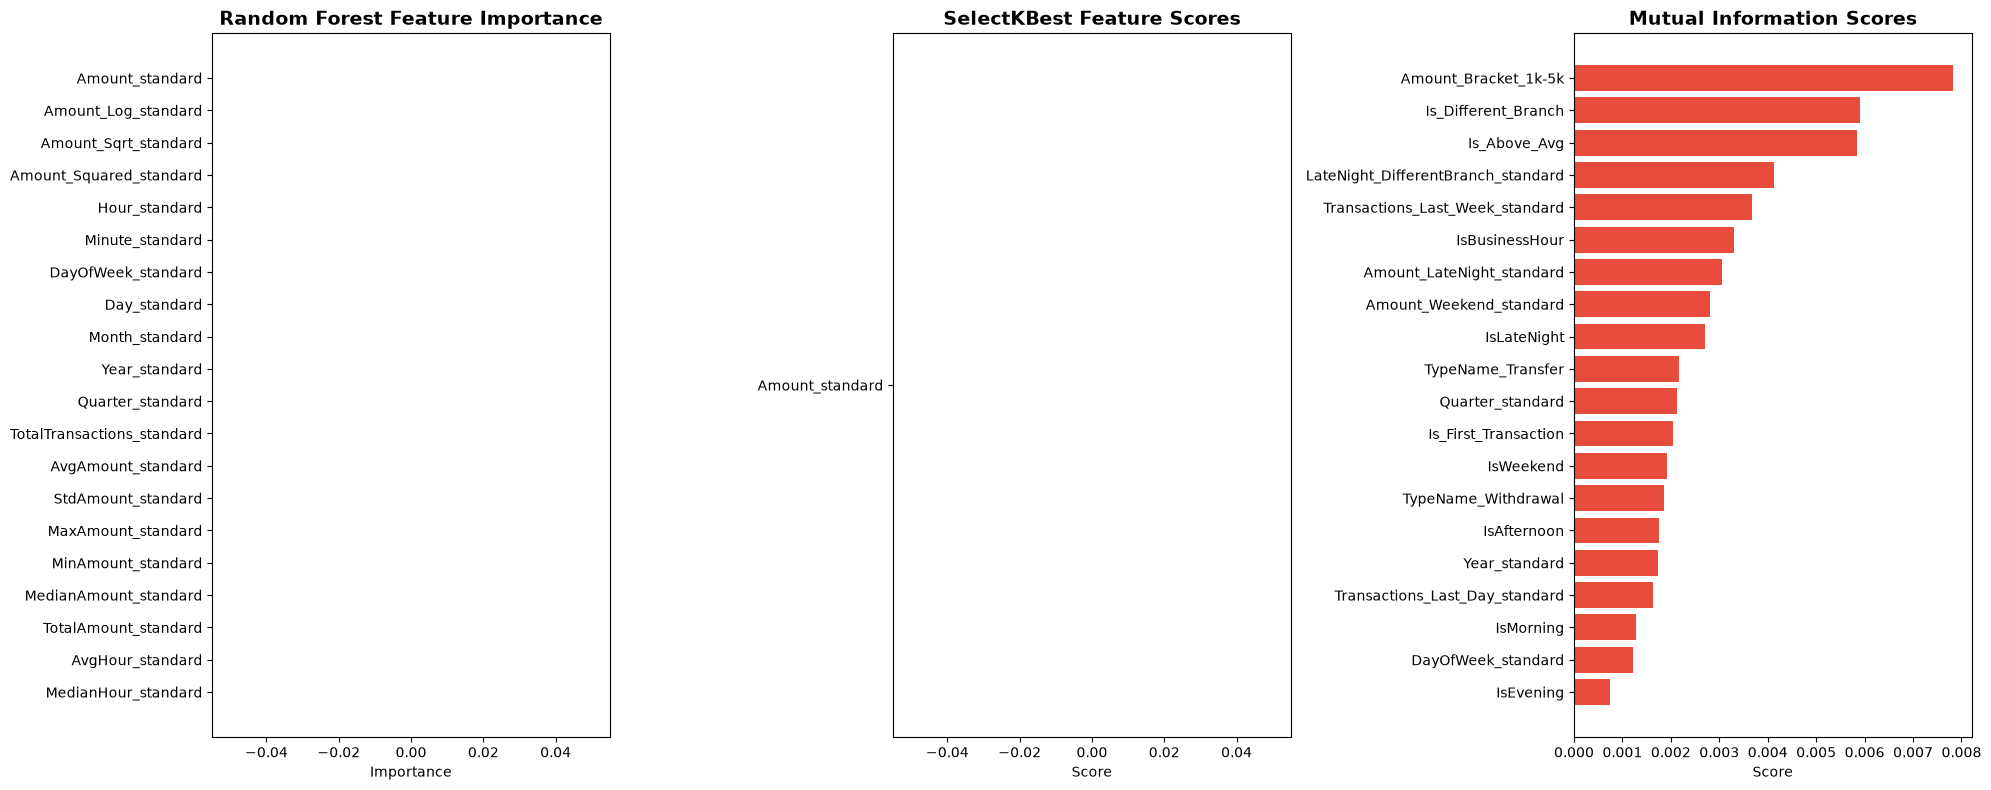

In [18]:
print("\n📊 Visualizing Feature Importance...")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Random Forest Importance
top_20_rf = feature_importance_rf.head(20)
axes[0].barh(top_20_rf['Feature'], top_20_rf['Importance'], color='#3498db')
axes[0].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# SelectKBest Scores
top_20_kbest = feature_scores_kbest.head(20)
axes[1].barh(top_20_kbest['Feature'], top_20_kbest['Score'], color='#2ecc71')
axes[1].set_title('SelectKBest Feature Scores', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].invert_yaxis()

# Mutual Information Scores
top_20_mi = feature_scores_mi.head(20)
axes[2].barh(top_20_mi['Feature'], top_20_mi['Score'], color='#e74c3c')
axes[2].set_title('Mutual Information Scores', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


# SAVE FINAL DATASET

In [19]:
print("\n" + "="*80)
print("💾 SAVING FINAL DATASETS")
print("="*80)

# Create final dataset with selected features
X_selected = X[selected_features].copy()
X_selected['Target'] = y

# Save full feature set
X_selected.to_csv('../data/eda/features_selected.csv', index=False)
print(f"   ✅ Saved selected features: ../data/eda/features_selected.csv ({X_selected.shape[1]} columns)")

# Save feature importance
feature_importance_rf.to_csv('../data/eda/feature_importance.csv', index=False)
print(f"   ✅ Saved feature importance: ../data/eda/feature_importance.csv")


💾 SAVING FINAL DATASETS
   ✅ Saved selected features: ../data/eda/features_selected.csv (31 columns)
   ✅ Saved feature importance: ../data/eda/feature_importance.csv


In [20]:
print("\n" + "="*80)
print("📊 FEATURE ENGINEERING SUMMARY")
print("="*80)

print(f"""
📋 Pipeline Summary:
─────────────────────────────
1. New Features Created
   • Time Features: 13 features
   • Amount Features: 7 features
   • Behavioral Features: 6 features
   • Frequency Features: 7 features
   • Location Features: 1 feature
   • Interaction Features: 5 features

2. Feature Encoding
   • One-Hot Encoding: {len(nominal_features)} features → {df_encoded.shape[1] if nominal_features else 0} new features
   • Binary Encoding: {len(binary_features)} features

3. Feature Scaling
   • {len(numerical_features)} features scaled using StandardScaler

4. Feature Selection
   • Random Forest: {k_features} features selected
   • SelectKBest: {k_features} features selected
   • Mutual Information: {k_features} features selected
   • Final Selected: {len(selected_features)} features

5. Output Files
   • features_selected.csv: {X_selected.shape[1]} columns
   • feature_importance.csv: Feature importance rankings
""")

print("\n" + "="*80)
print("✅ FEATURE ENGINEERING COMPLETED!")
print("="*80)


📊 FEATURE ENGINEERING SUMMARY

📋 Pipeline Summary:
─────────────────────────────
1. New Features Created
   • Time Features: 13 features
   • Amount Features: 7 features
   • Behavioral Features: 6 features
   • Frequency Features: 7 features
   • Location Features: 1 feature
   • Interaction Features: 5 features

2. Feature Encoding
   • One-Hot Encoding: 2 features → 11 new features
   • Binary Encoding: 15 features

3. Feature Scaling
   • 36 features scaled using StandardScaler

4. Feature Selection
   • Random Forest: 30 features selected
   • SelectKBest: 30 features selected
   • Mutual Information: 30 features selected
   • Final Selected: 30 features

5. Output Files
   • features_selected.csv: 31 columns
   • feature_importance.csv: Feature importance rankings


✅ FEATURE ENGINEERING COMPLETED!
